In [1]:
import json
# import plotly.express as px
import pandas as pd
# import openpyxl
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [2]:
with open('Deterministic_results_F_Q_I_S_MMR_Penta_as_antigen.json') as json_file:
    F_results = json.load(json_file)


In [3]:
start_DF = pd.read_excel('Starting_point.xlsx', sheet_name='F_start')
# Get the number of rows in the DataFrame
num_rows = len(start_DF)

# Create a new column 'Value' with a specified length
start_DF['Value'] = [1.0] * num_rows
start_DF.rename(columns={'Antigen': 'Tender'}, inplace=True)
start_DF.rename(columns={'Starting': 'Start'}, inplace=True)
start_DF.rename(columns={'Ending': 'Finish'}, inplace=True)
start_DF

,Tender,Start,Finish,Value
0,Measles,1,3,1.0
1,Mumps,1,3,1.0
2,Rubella,1,3,1.0
3,Diphtheria,1,1,1.0
4,Tetanus,1,1,1.0
5,Pertussis,1,1,1.0
6,Hib,1,1,1.0
7,Hepatitis_B,1,1,1.0
8,Polio,1,1,1.0
9,HPV,1,5,1.0


In [4]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["F"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})


In [5]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in grouped_results['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)

# remove ongoing tenders by merging start DF and droping columns
result_df = F_values_df.merge(start_DF, on=['Tender', 'Start'], how='left', indicator=True).query('_merge == "left_only"').drop('_merge', axis=1)
result_df.drop(columns=['Finish_y'], inplace=True)
result_df.drop(columns=['Value_y'], inplace=True)
result_df.rename(columns={'Finish_x': 'Finish'}, inplace=True)
result_df.rename(columns={'Value_x': 'Value'}, inplace=True)

#re-order tenders
# Convert the 'Tender' column to a categorical data type with the specified order
# Define the desired order
tender_order = ['Measles', 'Mumps', 'Rubella', 'MMR', 'Diphtheria', 'Tetanus', 'Pertussis', 'Hib', 'Polio', 'Hepatitis_B','HPV', 'PCV', 'Rotavirus']
result_df['Tender'] = pd.Categorical(result_df['Tender'], categories=tender_order, ordered=True)
# Sort the DataFrame based on the categorical order
result_df = result_df.sort_values('Tender')
result_df

,Tender,Start,Finish,Value
2309,Measles,3,5,-0.0
272,Measles,14,17,-0.0
1542,Measles,8,12,-0.0
1536,Measles,29,33,-0.0
1530,Measles,10,11,-0.0
...,...,...,...,...
2235,NaN,24,26,-0.0
2250,NaN,3,6,-0.0
2273,NaN,19,22,-0.0
2290,NaN,20,22,-0.0


In [6]:
result_df[(result_df.Tender == "MMR") & (result_df.Value == 1)]

,Tender,Start,Finish,Value
743,MMR,26,30,1.0
670,MMR,16,20,1.0
1698,MMR,6,10,1.0
781,MMR,1,5,1.0
1210,MMR,21,25,1.0
912,MMR,31,35,1.0
1492,MMR,11,15,1.0


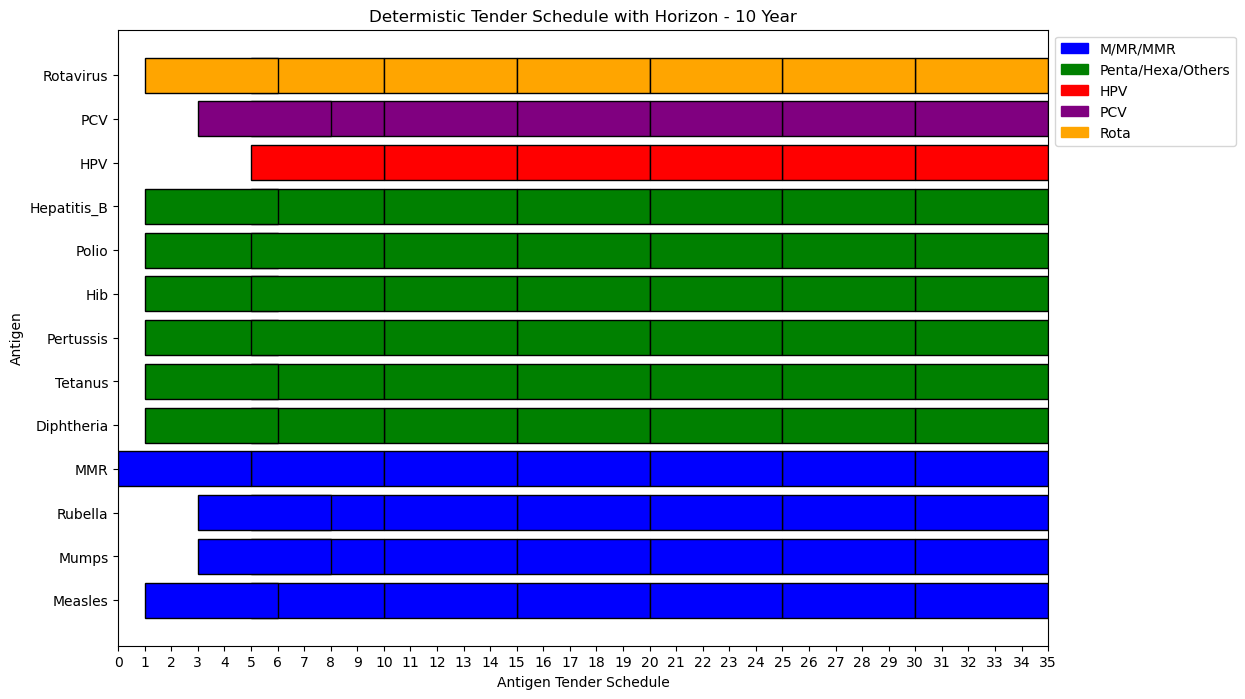

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


# Define color groups
color_groups = {
    'M/MR/MMR': ['Measles', 'Mumps', 'Rubella', 'MMR'],
    'Penta/Hexa/Others': ['Diphtheria', 'Tetanus', 'Pertussis', 'Hib', 'Polio', 'Hepatitis_B'],
    'HPV': ['HPV'],
    'PCV': ['PCV'],
    'Rota': ['Rotavirus'],
}

# fig, ax = plt.subplots(figsize=(10, 5))
fig, ax = plt.subplots(figsize=(12, 8))  # Adjust figure size

# Define colors for each group
colors = {
    'M/MR/MMR': 'blue',
    'MMR': 'light blue',
    'Penta/Hexa/Others': 'green',
    'HPV': 'red',
    'PCV': 'purple',
    'Rota': 'orange',
}

# # Iterate through rows and plot bars based on conditions and color groups
# for index, row in result_df.iterrows():
#     if round(row['Value']) == 1:
#         start = row['Start'] - 1
#         end = row['Finish']
        
#         # Choose color based on the group
#         for group, tenders in color_groups.items():
#             if row['Tender'] in tenders:
#                 color = colors[group]
#                 ax.barh(row['Tender'], width=end - start, left=start, edgecolor='black', color=color)

# Iterate through rows and plot bars based on conditions and color groups
for index, row in result_df.iterrows():
    if round(row['Value']) == 1:
        start = row['Start'] - 1
        end = row['Finish']
        
        # Choose color based on the group
        for group, tenders in color_groups.items():
            if row['Tender'] in tenders:
                color = colors[group]
                # Adjust 'left' parameter for overlapping bars
                ax.barh(row['Tender'], width=end - start, left=start, edgecolor='black', color=color)


# Set labels and show the plot
ax.set_xlim(0, 35)
ax.set_xticks(range(36))

ax.set_xlabel('Antigen Tender Schedule')
ax.set_ylabel('Antigen')
plt.title('Determistic Tender Schedule with Horizon - 10 Year')

# Create a legend with adjusted location
legend_labels = [plt.Rectangle((0, 0), 1, 1, color=colors[group], label=group) for group in color_groups.keys()]
ax.legend(handles=legend_labels, labels=color_groups.keys(), loc='upper left', bbox_to_anchor=(1, 1))


# Add a dashed yellow line at the 10th tick on the x-axis
# ax.axvline(x=10.04, color='yellow', linestyle='--', linewidth=2)

# Save and show the plot
# plt.savefig('Deterministic_Tenders_With_Start_Color_Groups_Same_Color.png')
plt.savefig('Deterministic_results_F_Q_I_S_30_TENDERS.png', bbox_inches='tight', pad_inches=0.1)
plt.show()
plt.show()
